In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd

# Ensure the notebook can find the /src directory
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [2]:
from src.data_loader import VesselDataLoader
from src.visualizer import (
    plot_block_space, 
    plot_mode_statistics, 
    plot_series,
    plot_scenario_tradeoff_space,         # New
)
from src.data_processing import engineer_telemetry_features
from src.mission_profiler import MissionProfiler, ScenarioManager

Processing Rotherhithe_voy_179.csv...

[BATTERY DEPLOYMENT METRICS FOR Rotherhithe_voy_179.csv]:
  -> Worst-Case Causal Power Peak Required: 431.2 kW
  -> Min Energy Capacity Excursion Integral: 867.7 kWh

Processing Wembley_voy_236.csv...

[BATTERY DEPLOYMENT METRICS FOR Wembley_voy_236.csv]:
  -> Worst-Case Causal Power Peak Required: 357.2 kW
  -> Min Energy Capacity Excursion Integral: 953.9 kWh



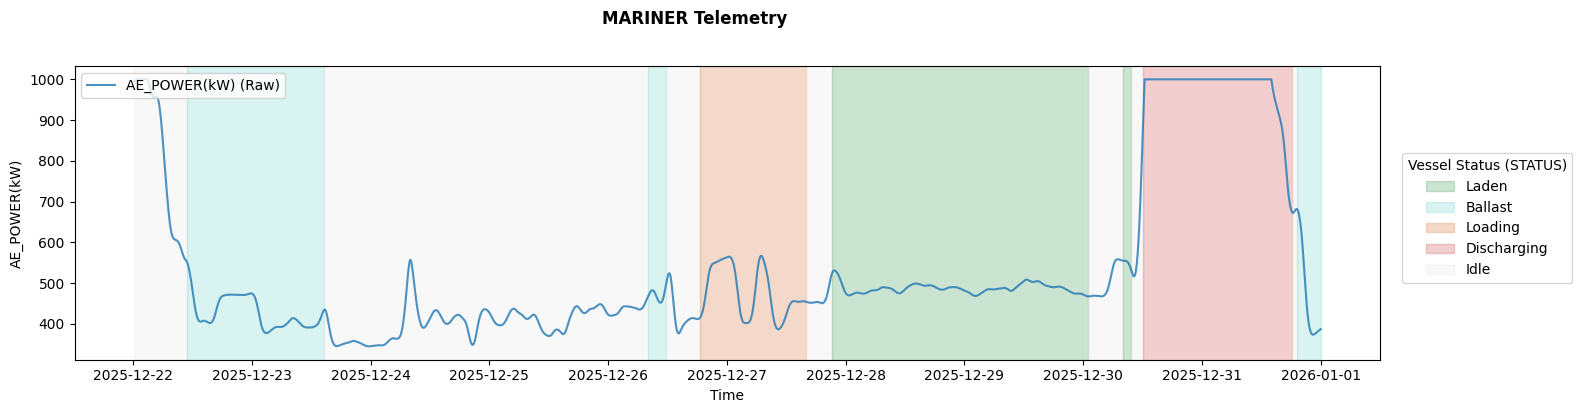

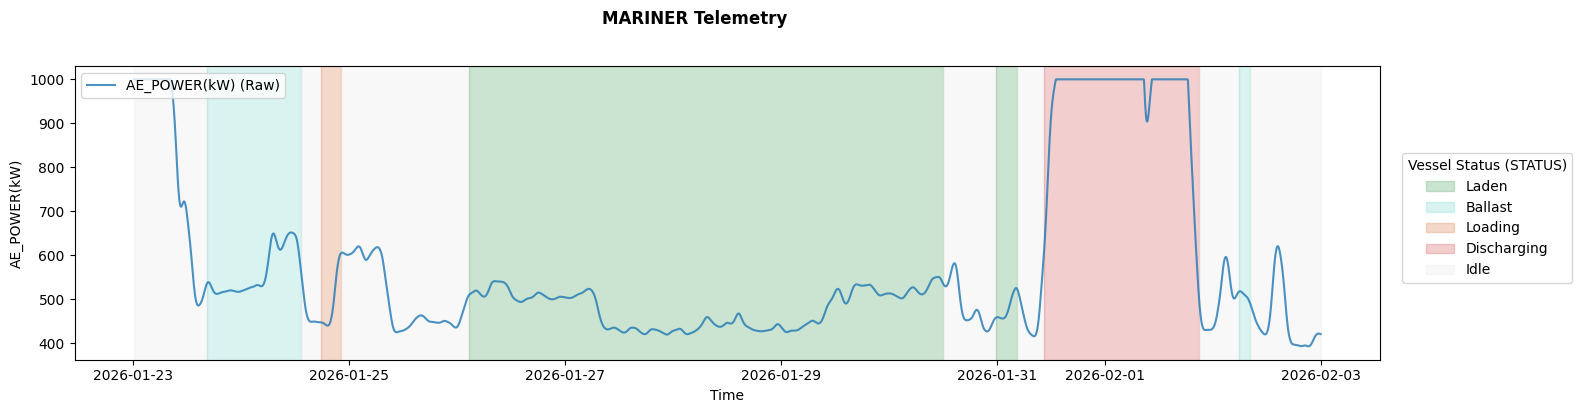

In [3]:
filenames = ["Rotherhithe_voy_179.csv", "Wembley_voy_236.csv" ]
filtered_registry_entries = []

profiler = MissionProfiler(speed_threshold=1.0)

for filename in filenames:
    print(f"Processing {filename}...")
    
    # 1. Load and process
    raw_data_file = root_path / "data" / "raw" / filename
    loader = VesselDataLoader(raw_data_file)
    raw_df = loader.load_and_clean()
    
    # Applying low-pass filtering automatically computes the inline battery specs
    filtered_df = engineer_telemetry_features(raw_df, filter_method='butter')
    
    # Inspect battery limits for the hardware envelope tracking
    battery_metrics = filtered_df.attrs.get('battery_specs', {})
    print(f"\n[BATTERY DEPLOYMENT METRICS FOR {filename}]:")
    print(f"  -> Worst-Case Causal Power Peak Required: {battery_metrics.get('worst_case_power_peak_kW', 0.0):.1f} kW")
    print(f"  -> Min Energy Capacity Excursion Integral: {battery_metrics.get('min_capacity_excursion_kWh', 0.0):.1f} kWh\n")
    
    # 2. Generate Low-Pass Filtered Block Registries (Target Architecture Base)
    filtered_registry_df = profiler.generate_block_registry(
        filtered_df, 
        source_file_name=filename, 
        merge_loitering=False, 
        unify_port_ops=False
    )
    filtered_registry_entries.append(filtered_registry_df)
    
    # Keep standard validation diagnostic visualizations active
    plot_series(filtered_df, ['AE_POWER(kW)'])

# 3. Concatenate all blocks and generate mathematically consistent global stats
combined_filtered_registry = pd.concat(filtered_registry_entries, ignore_index=True)
combined_filtered_stats = profiler.extract_global_statistics(combined_filtered_registry)

In [7]:
# ==============================================================================
# ADAPTED CELL: SWEEPING FILTERS ON PRE-CLASSIFIED VOYAGE DATA
# ==============================================================================

# Define our filter cutoff array
cutoff_presets = [0.40, 0.20, 0.10, 0.05, 0.02, 0.01]

# CRITICAL FIX: Match the exact CamelCase strings generated by classify_modes()
evaluation_runs = {
    "Full Spectrum (Including Port Cargo Load)": [],
    "Transit & Maneuvering Only (Excluding Port Cargo Load)": ['Port_Loading', 'Port_Unloading']
}

if 'raw_df' in locals() and raw_df is not None:
    print("Pre-calculating operational modes and stay_id tracking grids...")
    
    # 1. Establish a temporary raw baseline to extract voyage blocks
    # We use raw filtering to build the structural roadmap without smoothing artifacts
    raw_features_df = engineer_telemetry_features(raw_df.copy(), filter_method='raw')
    
    # 2. Run the profiler once to map out continuous 'stay_id' boundaries across the dataset
    profiler = MissionProfiler(speed_threshold=1.0)
    base_classified = profiler.classify_modes(raw_features_df)
    
    # Ensure our status check falls back onto the cleanly mapped 'MODE' column
    # by duplicating it to 'STATUS' if your filter code expects 'STATUS'
    base_classified['STATUS'] = base_classified['MODE']

    # 3. Execute the filter parameter sweep over the mapped layout
    for run_name, ignore_list in evaluation_runs.items():
        print(f"\n--- EVALUATING CONFIGURATION: {run_name} ---")
        battery_sweep_records = []
        
        for fc in cutoff_presets:
            tau_minutes = (600.0 / (2.0 * 3.14159 * fc)) / 60.0
            
            # Forward the pre-classified dataframe containing stay_id and normalized modes
            sweep_filtered_df = engineer_telemetry_features(
                base_classified, 
                filter_method='butter', 
                cutoff=fc, 
                ignore_modes=ignore_list
            )
            
            specs = sweep_filtered_df.attrs.get('battery_specs', {})
            
            if specs:
                installed_capacity_buffer_60pc = specs['min_capacity_excursion_kWh'] / 0.60
                battery_sweep_records.append({
                    'Cutoff (fc)': fc,
                    'Time Constant (τ)': f"~{tau_minutes:.1f} min",
                    'Max Inverter (kW)': round(specs['worst_case_power_peak_kW'], 1),
                    'Min Usable (kWh)': round(specs['min_capacity_excursion_kWh'], 1),
                    'Est installed Pack (kWh)': round(installed_capacity_buffer_60pc, 1)
                })
                
        df_battery_sweep = pd.DataFrame(battery_sweep_records)
        print(df_battery_sweep.to_string(index=False))
else:
    print("ERROR: 'raw_df' not found in local workspace environment.")

Pre-calculating operational modes and stay_id tracking grids...

--- EVALUATING CONFIGURATION: Full Spectrum (Including Port Cargo Load) ---
 Cutoff (fc) Time Constant (τ)  Max Inverter (kW)  Min Usable (kWh)  Est installed Pack (kWh)
        0.40          ~4.0 min              261.7            1781.1                    2968.5
        0.20          ~8.0 min              261.7            1781.2                    2968.7
        0.10         ~15.9 min              295.0            1769.6                    2949.4
        0.05         ~31.8 min              357.2            1745.6                    2909.4
        0.02         ~79.6 min              423.2            1769.3                    2948.8
        0.01        ~159.2 min              423.2            2208.8                    3681.3

--- EVALUATING CONFIGURATION: Transit & Maneuvering Only (Excluding Port Cargo Load) ---
 Cutoff (fc) Time Constant (τ)  Max Inverter (kW)  Min Usable (kWh)  Est installed Pack (kWh)
        0.40     

In [5]:
fig_bricks_fatigue = plot_block_space(combined_filtered_registry, y_axis_metric='Relative_Fatigue_Activity_Rate', print_table=False)
fig_bricks_fatigue.show()

fig_stats_fatigue = plot_mode_statistics(combined_filtered_stats, y_axis_metric='Relative_Fatigue_Activity_Rate', print_table=False)
fig_stats_fatigue.show()

In [6]:
# Instantiate the Scenario Manager with our combined filtered dataset components
manager = ScenarioManager(registry_df=combined_filtered_registry, global_stats=combined_filtered_stats)

# Execute the single point-of-entry pipeline method to evaluate weights across all 4 modes
compiled_scenario_outputs = manager.run_full_scenario_pipeline(total_target_h=1000.0, print_summary=True)

# Render Degradation Index vs H2 Flow Optimization Chart
fig_tradeoff = plot_scenario_tradeoff_space(compiled_scenario_outputs)
fig_tradeoff.show()

  Scenario Profile         Data Strategy  Energy Demanded (kWh)  \
0         Baseline      Full Run Average               541750.3   
1         Baseline  Bottom 25% Optimized               523402.4   
2      Shore_Power      Full Run Average               473193.8   
3      Shore_Power  Bottom 25% Optimized               446291.7   
4   PEMFC_Off_Port      Full Run Average               469441.2   
5   PEMFC_Off_Port  Bottom 25% Optimized               447606.1   
6       Long_Trips      Full Run Average               529511.9   
7       Long_Trips  Bottom 25% Optimized               518478.6   

   H2 Mass Min [η=0.55] (kg)  H2 Mass Max [η=0.45] (kg)  Fatigue Index  \
0                    29561.8                    36131.1       37.25516   
1                    28560.6                    34907.5       40.02418   
2                    25820.9                    31558.9       33.80679   
3                    24352.9                    29764.7       24.68764   
4                    25616